# **Exercise 4 (Data Standardization Before PCA)**

In this exercise we will analyze the effect of pre-processing the data by standardizing it before applying PCA. 

We will use a very simple dataset with two quantitative variables (height and weight) mesured on 100 humans. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [102]:
# Read the data
df = pd.read_csv('SOCR-HeightWeight_small.csv')

# Explore if there are values to imput:
if df.isnull().sum()[0]==0 and df.isnull().sum()[1]==0:
    print('There are no missing values.')
else:
    print(df.isnull().sum().to_string())

There are no missing values.


### **a) Plotting the data before and after PCA**

In this part of the exercise we will plot the data. We will set the axis ratio to one to stablish cohesion and consistency with the coming PCA graphics.

After that, we will perform PCA on the data and compare the new graph with the original data one. The fixed ratio axis will allow us to get better comparisons.

To end with this part, we will compute the cumulative explained variance and the contributions of each variable to the principal components to establish the relationship with the original set and the PCA one.

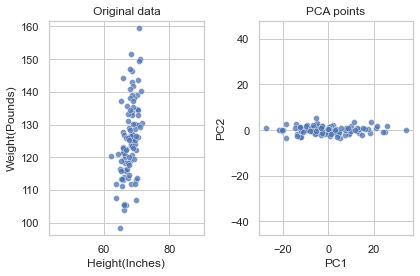

In [90]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2)

# Original data plot:
sns.scatterplot(data=df,x="Height(Inches)", y="Weight(Pounds)", alpha=0.75,ax=axes[0])
plt.xlabel('Height(Inches)')
plt.ylabel('Weight(Pounds)')
#plt.gca().set_aspect('equal', adjustable='box')
plt.axis('equal')
axes[0].set_title("Original data")

# Performing PCA
pca = PCA()
pca.fit(df)
X_pca=pca.transform(df)

# Create a DataFrame for the 2 components
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(2)])

# PCA points plot
sns.scatterplot(data=pca_df,x='PC1',y='PC2', alpha=0.75,ax=axes[1])
plt.xlabel('PC1')
plt.ylabel('PC2')
#plt.gca().set_aspect('equal', adjustable='box')
plt.axis('equal')
axes[1].set_title("PCA points")

for ax in axes:
    ax.axis('equal')

plt.tight_layout()
plt.show()



From the 'original data' plot we can tell that 'weight' has a much more larger variance than 'height'. This direction of large variance is associated to an eigenvector that corresponds to a big eigenvalue. This will dominate the PCA model.

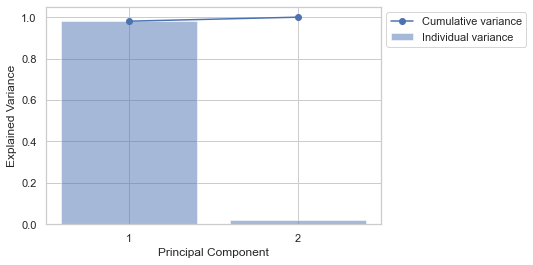

  Principal Component  Explained Variance  Cumulative Variance
0                 PC1            0.980596             0.980596
1                 PC2            0.019404             1.000000


In [ ]:
# Cumulative explained variance 
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Cumulative and explained variance plot
plt.plot([1, 2], cumulative_variance, marker='o', label="Cumulative variance")
plt.bar([1, 2], explained_variance_ratio, alpha=0.5, label="Individual variance")
plt.xticks([1, 2])
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

table = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance_ratio))],
    "Explained Variance": explained_variance_ratio,
    "Cumulative Variance": cumulative_variance
})

print(table)


In [72]:
# Contributions of each variable to the principal components.

# They are stored in pca.components_
contributions = pca.components_

table_contr=pd.DataFrame({
    "Variables": df.columns,
    "PC1": contributions[0],
    "PC2": contributions[1]
})
print(table_contr)

        Variables       PC1       PC2
0  Height(Inches)  0.083252 -0.996528
1  Weight(Pounds)  0.996528  0.083252


From this part of the exercise, we have learnt that the first principal component explaines more than 98% of the information of the original data, that is, PC1 contains almost all information about the original data. This is also noticeable in the plots, because PC2's range is really limited. Therfore, we can claim that the dataset is almost uni-dimensional.

Moreover, we can tell that the variable 'weight' contributes directly a lot to the creation of this first PC, while the variable 'height' contribute in an inverse way to the second PC. Consequently, PC1 represents mostly the behaviour of 'weight' and PC2 the one of 'height'.

Because of that, we can say that each original varible dominates a different component. But, since PC1 explains 98% of the information, the PCA system is representing only one variablity direction porperly. 

### **b) Changing the units**

Lets repeat the first part but with metric units:
- 1 inch = 0,0254 m
- 1 pound = 0,453592 kg

In [82]:
#New data set:

df_metric=df.copy()
df_metric.iloc[:,0]=df.iloc[:,0]*0.0254
df_metric.iloc[:,1]=df.iloc[:,1]* 0.453592
df_metric.columns=['Height(m)','Weight(kg)']

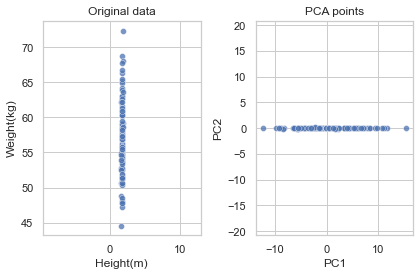

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2)

# Original data plot:
sns.scatterplot(data=df_metric,x="Height(m)", y="Weight(kg)", alpha=0.75,ax=axes[0])
plt.xlabel('Height(m)')
plt.ylabel('Weight(kg)')
plt.gca().set_aspect('equal', adjustable='box')
axes[0].set_title("Original data")

# Performing PCA
pca = PCA()
pca.fit(df_metric)
X_pca_metric=pca.transform(df_metric)

# Create a DataFrame for the 2 components
pca_df_metric = pd.DataFrame(X_pca_metric, columns=[f'PC{i+1}' for i in range(2)])

# PCA points plot
sns.scatterplot(data=pca_df_metric,x='PC1',y='PC2', alpha=0.75,ax=axes[1])
plt.xlabel('PC1')
plt.ylabel('PC2')
#plt.gca().set_aspect('equal', adjustable='box')
plt.axis('equal')
axes[1].set_title("PCA points")

for ax in axes:
    ax.axis('equal')

plt.tight_layout()
plt.show()



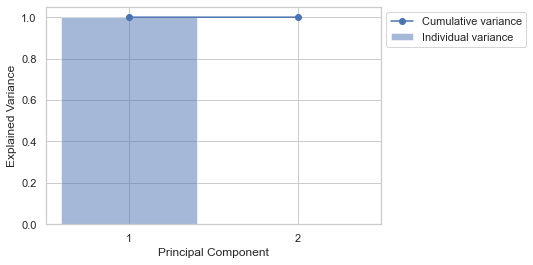

  Principal Component  Explained Variance  Cumulative Variance
0                 PC1            0.999937             0.999937
1                 PC2            0.000063             1.000000


In [87]:
# Cumulative explained variance 
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Cumulative and explained variance plot
plt.plot([1, 2], cumulative_variance, marker='o', label="Cumulative variance")
plt.bar([1, 2], explained_variance_ratio, alpha=0.5, label="Individual variance")
plt.xticks([1, 2])
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

table = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance_ratio))],
    "Explained Variance": explained_variance_ratio,
    "Cumulative Variance": cumulative_variance
})

print(table)


In [88]:
# Contributions of each variable to the principal components.

# They are stored in pca.components_
contributions = pca.components_

table_contr=pd.DataFrame({
    "Variables": df.columns,
    "PC1": contributions[0],
    "PC2": contributions[1]
})
print(table_contr)

        Variables       PC1       PC2
0  Height(Inches)  0.004585 -0.999989
1  Weight(Pounds)  0.999989  0.004585


The conclusions that we can obtain after changing the units are the same ones. However, now the contributions are even more extreme in the sense that PC1 explains almost completely the behaviour of the weight and PC2 almost completely the behaviour of the height. Also, PC1 now explains more than 99% of the original information.

This changes are because of the transformation that causes $Var(Y)=a**2Var(X)$. In the case of the height with $a=0,0254 < 0,453592$, the new variance is much smaller and the difference with the weight's variance is larger. 

### **c) Standardizing data**

Lets repeat the fisrt part but previously standardizing the data.

In [93]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

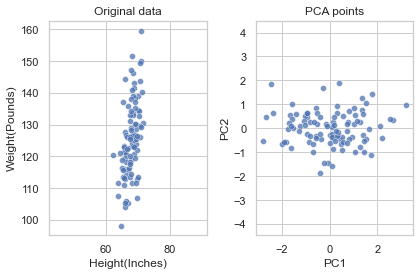

In [96]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2)

# Original data plot:
sns.scatterplot(data=df,x="Height(Inches)", y="Weight(Pounds)", alpha=0.75,ax=axes[0])
plt.xlabel('Height(Inches)')
plt.ylabel('Weight(Pounds)')
#plt.gca().set_aspect('equal', adjustable='box')
plt.axis('equal')
axes[0].set_title("Original data")

# Performing PCA
pca = PCA()
pca.fit(X_scaled)
X_pca_scaled=pca.transform(X_scaled)

# Create a DataFrame for the 2 components
pca_df_scaled = pd.DataFrame(X_pca_scaled, columns=[f'PC{i+1}' for i in range(2)])

# PCA points plot
sns.scatterplot(data=pca_df_scaled,x='PC1',y='PC2', alpha=0.75,ax=axes[1])
plt.xlabel('PC1')
plt.ylabel('PC2')
#plt.gca().set_aspect('equal', adjustable='box')
plt.axis('equal')
axes[1].set_title("PCA points")

for ax in axes:
    ax.axis('equal')

plt.tight_layout()
plt.show()



Now we can see in the plot that the PCA points are more widely distributed in the PC2 axis, not only in the PC1. This involves that the PC2 is now explaining a bigger proportion of the original data. We will calculate the cummulative and individual variances to make this point sure.

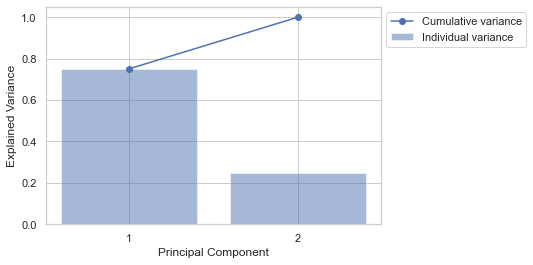

  Principal Component  Explained Variance  Cumulative Variance
0                 PC1            0.750245             0.750245
1                 PC2            0.249755             1.000000


In [97]:
# Cumulative explained variance 
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Cumulative and explained variance plot
plt.plot([1, 2], cumulative_variance, marker='o', label="Cumulative variance")
plt.bar([1, 2], explained_variance_ratio, alpha=0.5, label="Individual variance")
plt.xticks([1, 2])
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

table = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance_ratio))],
    "Explained Variance": explained_variance_ratio,
    "Cumulative Variance": cumulative_variance
})

print(table)


As we suposed, PC1 now explains 75% of the original data and PC2 the 25% missing. 

Lets now analyze the contributions.

In [98]:
# Contributions of each variable to the principal components.

# They are stored in pca.components_
contributions = pca.components_

table_contr=pd.DataFrame({
    "Variables": df.columns,
    "PC1": contributions[0],
    "PC2": contributions[1]
})
print(table_contr)

        Variables       PC1       PC2
0  Height(Inches)  0.707107 -0.707107
1  Weight(Pounds)  0.707107  0.707107


Now we can tell that 'Height' and 'Weight' contribute equally to PC1. They also contribute in the same magnitude to PC2, but 'Height' does it in an inverse way: when height increases, PC2 decreases. So each PC explains the behaviour of each variable in the same amount the projection is not favouring any of them.

For the last question, it does not matter if we standrize the original data or the data in the metric units. This is because changing the units is a linear transformation of the type $y=a*x$ that we apply to the original datset and standardization is invariant to this kind of transformtion because the mean and the standard deviation vary in the same way.

### **d) Is standardization recommended?**

Firstly, lets compute the variances of the original variables:

In [99]:
df.var()

Height(Inches)      3.631663
Weight(Pounds)    135.694743
dtype: float64

As we could tell from the first two parts of the exercise, the variable 'weight' has a much more larger variance than the variable 'height'. We could tell this because the PCA transformation gives more importance to the variables that have more variance and this was reflected in the way that the PC that explained almost the totality of the original information was directly related to 'weight'. 

On the grounds of this variance imbalance, the comparisons before standrizing the data were not fair or interpretable because true structure and correlation was not reflected. The PCA model was dominated by the variable with a larger variance. 

To give sense to the principal components, it is needed to get a common scale for the attributes, and this is achieved by standardizing the data. After doing this, comparisons can be made because all the variables are equally represented.

### **e) Effects of standardization**

**e.1) Lectures and exercises evaluation**

In this case we have two variables: e1='evaluation of the  lectures' and e2='evaluation of the exercises'. This two variables do not have a common scale because the range of e2 is wider. This involves a bigger variance for e2 and therefore, this variable would dominate the PCA model. Then the “difficulty score” mostly would reflect exercise difficulty, not overall module perception. 

In consequence, we previously need to standardize the data. After standardizing the data and applying a PCA model we could observe the clusters formed by the groups of student based on their overall opinion of the evaluation.

**e.2) Length of bones**

Here we have the variables corresponding to the measures of the differents bones. All the measurements are on a common scale but we do not know if the different bones present very differents ranges of possible measures. Therefore, we could not assure if its is better to standardize the data before or not.

In the case that all the bones have a similar range, their variance would be similar. So, in this situation, because data is ready to apply a PCA model, it is not recommended to standardize the data because this could involve amplifying noise or unrealistic variations.

But if there is a certain bone that varies a lot from one patient to another or that is much longer, the variable related to this bone would dominate the PCA model and clustering would be driven mostly by large bones. In this situation, we would have to standardize the data.

